# 02B — Revised 30-s CPLEX / simulated-annealing benchmark

This is the **go/no-go notebook before the final 20-event D-Wave hybrid campaign**.

All solvers use the same 945-bit field-calibrated job-start + DVFS-mode candidate set. `CPLEX-QUBO` and simulated annealing solve the identical unconstrained BQM. `CPLEX-constrained` is a native physical MIQP reference using the same binaries, with explicit one-job/one-mode and curtailment-envelope constraints.

The default test is only the first three CAISO events.

In [1]:
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ai_spot_curtailment_dvfs_qubo_core import (
    StudyConfig, build_qubo, random_equivalence_tests,
    solve_cplex_qubo, solve_cplex_constrained_reference, solve_sa_qubo,
    decode_sample, qubo_energy
)

DATA = Path("prepared_ai_curtailment_dvfs")
OUT = Path("revised_initial_solver_results")
OUT.mkdir(exist_ok=True)

manifest = json.loads((DATA/"revised_data_and_qubo_manifest.json").read_text())
cfg_dict = manifest["config"].copy()
cfg_dict["dvfs_caps_W"] = tuple(cfg_dict["dvfs_caps_W"])
CFG = StudyConfig(**cfg_dict)

SCENARIOS_TO_TEST = [0,1,2]
RUN_CPLEX_QUBO = True
RUN_CPLEX_CONSTRAINED_REFERENCE = True
RUN_SA = True
CPLEX_LOG_OUTPUT = False

portfolio = pd.read_csv(DATA/"benchmark_spot_jobs_dvfs.csv")
cal = pd.read_csv(DATA/"emerald_dvfs_calibration.csv")
profiles = pd.read_csv(DATA/"event_profiles_long.csv", parse_dates=["timestamp"])
events = pd.read_csv(DATA/"selected_caiso_events.csv", parse_dates=["start","end"])

print(f"Frozen model: {manifest['qubo_variables']} binaries, {manifest['qubo_edges']:,} edges, density={100*manifest['qubo_density']:.2f}%")
print(f"CPLEX time limit: {CFG.cplex_time_limit_s:g} s")
print(f"SA: {CFG.sa_num_reads} reads x {CFG.sa_num_sweeps} sweeps (chosen to be ~30-s scale based on the first benchmark)")

Frozen model: 945 binaries, 419,814 edges, density=94.12%
CPLEX time limit: 30 s
SA: 1000 reads x 5000 sweeps (chosen to be ~30-s scale based on the first benchmark)


In [2]:
ep0 = profiles[profiles.event_id==SCENARIOS_TO_TEST[0]].copy()
q0 = build_qubo(portfolio, cal, ep0, CFG)
assert q0['n_variables'] <= 1000
assert CFG.lambda_once > q0['lambda_sufficient_bound']
eq = random_equivalence_tests(q0, portfolio, ep0, CFG, n_tests=20, seed=99)
display(eq)
assert eq.abs_error.max() < 1e-8

,test,direct,qubo,abs_error
0,0,177.311687,177.311687,2.842171e-14
1,1,219.343608,219.343608,2.842171e-14
2,2,294.817869,294.817869,1.705303e-13
3,3,437.507507,437.507507,5.684342e-14
4,4,312.390518,312.390518,1.136868e-13
5,5,348.330272,348.330272,0.000000e+00
6,6,333.685709,333.685709,5.684342e-14
7,7,479.335938,479.335938,1.705303e-13
8,8,303.598495,303.598495,5.684342e-14
9,9,89.734009,89.734009,0.000000e+00


In [3]:
summary_rows = []
trajectory_rows = []
solution_bank = {}

for event_id in SCENARIOS_TO_TEST:
    print("\n" + "="*96)
    print("EVENT", event_id)
    ep = profiles[profiles.event_id==event_id].sort_values("slot").copy()
    q = build_qubo(portfolio, cal, ep, CFG)
    print(f"{q['n_variables']} binaries | {q['n_edges']:,} edges | density {100*q['density']:.2f}%")

    eq = random_equivalence_tests(q, portfolio, ep, CFG, n_tests=8, seed=1000+event_id)
    assert eq.abs_error.max() < 1e-8

    methods = []
    if RUN_CPLEX_QUBO:
        print("CPLEX-QUBO...")
        r = solve_cplex_qubo(q, CFG, time_limit_s=CFG.cplex_time_limit_s, log_output=CPLEX_LOG_OUTPUT)
        methods.append(("CPLEX-QUBO", r))
    if RUN_CPLEX_CONSTRAINED_REFERENCE:
        print("CPLEX constrained MIQP reference...")
        r = solve_cplex_constrained_reference(portfolio, cal, ep, CFG,
                                              time_limit_s=CFG.cplex_time_limit_s,
                                              log_output=CPLEX_LOG_OUTPUT)
        methods.append(("CPLEX-constrained", r))
    if RUN_SA:
        print("Simulated annealing...")
        r = solve_sa_qubo(q, CFG, seed=CFG.sa_seed + event_id)
        methods.append(("SA", r))

    for method, r in methods:
        if r.get('sample') is None:
            summary_rows.append({"event_id":event_id,"method":method,"wall_time_s":r.get('wall_time_s'),
                                 "status":r.get('status'),"best_bound":r.get('best_bound'),"mip_gap":r.get('mip_gap')})
            continue
        dec = decode_sample(r['sample'], portfolio, ep, q, CFG)
        e_re = qubo_energy(r['sample'], q, include_offset=True)
        if method != 'CPLEX-constrained':
            assert abs(e_re - dec['metrics']['objective_direct']) < 1e-7
        assert dec['metrics']['max_concurrent_gpus'] <= CFG.field_cluster_gpus
        row = {
            "event_id":event_id, "method":method,
            "solver_energy_reported":r.get('energy',np.nan),
            "qubo_energy_recomputed":e_re,
            "wall_time_s":r.get('wall_time_s',np.nan),
            "status":r.get('status','ok'),
            "best_bound":r.get('best_bound',np.nan),
            "mip_gap":r.get('mip_gap',np.nan),
            **dec['metrics'],
        }
        summary_rows.append(row)
        solution_bank[f"event{event_id}_{method}"] = r['sample']
        for t in range(CFG.T):
            trajectory_rows.append({
                "event_id":event_id,"method":method,"slot":t,
                "timestamp":ep.iloc[t].timestamp,
                "allocated_curtailment_kW":ep.iloc[t].allocated_curtailment_kW,
                "dispatch_target_kW":ep.iloc[t].dispatch_target_kW,
                "gpu_load_kW":dec['load_kW'][t],
                "active_gpus":dec['gpu_count'][t],
            })
        print(method, dec['metrics'])

summary = pd.DataFrame(summary_rows)
traj = pd.DataFrame(trajectory_rows)
summary.to_csv(OUT/"revised_solver_benchmark.csv", index=False)
traj.to_csv(OUT/"revised_solver_trajectories.csv", index=False)
np.savez_compressed(OUT/"revised_solution_bank.npz", **solution_bank)
display(summary)


EVENT 0
945 binaries | 419,814 edges | density 94.12%
CPLEX-QUBO...
CPLEX constrained MIQP reference...
Simulated annealing...
CPLEX-QUBO {'objective_direct': 0.23869690356790496, 'tracking_objective': 0.23869690356790496, 'once_penalty': 0.0, 'duplicate_starts': 0, 'n_jobs_scheduled': 9, 'tracking_RMSE_kW': 2.346049331245393, 'max_envelope_violation_kW': 0.0, 'envelope_violation_kWh': 0.0, 'max_concurrent_gpus': 70, 'cluster_gpu_capacity': 256, 'allocated_curtailment_kWh': 117.92975665997226, 'target_energy_kWh': 94.3438053279778, 'scheduled_gpu_energy_kWh': 91.19485632551613, 'renewable_absorbed_kWh': 91.19485632551613, 'capture_fraction_of_envelope': 0.7732980963274514, 'target_energy_ratio': 0.9666226204093142, 'completed_baseline_gpu_hours': 266.9525, 'cap250_jobs': 5, 'cap300_jobs': 3, 'cap350_jobs': 0, 'cap400_jobs': 1}
CPLEX-constrained {'objective_direct': 0.09200772957114137, 'tracking_objective': 0.09200772957114137, 'once_penalty': 0.0, 'duplicate_starts': 0, 'n_jobs_sched

,event_id,method,solver_energy_reported,qubo_energy_recomputed,wall_time_s,status,best_bound,mip_gap,objective_direct,tracking_objective,...,target_energy_kWh,scheduled_gpu_energy_kWh,renewable_absorbed_kWh,capture_fraction_of_envelope,target_energy_ratio,completed_baseline_gpu_hours,cap250_jobs,cap300_jobs,cap350_jobs,cap400_jobs
0,0,CPLEX-QUBO,0.238697,0.238697,30.078925,time limit exceeded,-1139.726197,4775.784170,0.238697,0.238697,...,94.343805,91.194856,91.194856,0.773298,0.966623,266.952500,5,3,0,1
1,0,CPLEX-constrained,0.092008,0.092008,30.165970,time limit exceeded,-13.003932,142.335215,0.092008,0.092008,...,94.343805,91.564486,91.564486,0.776432,0.970541,270.447222,9,0,0,2
2,0,SA,0.023259,0.023260,420.363740,ok,NaN,NaN,0.023260,0.023260,...,94.343805,96.853009,96.853009,0.821277,1.026596,266.963333,3,1,2,4
3,1,CPLEX-QUBO,0.105449,0.105449,30.057039,time limit exceeded,-1140.265657,10814.401818,0.105449,0.105449,...,93.832591,94.036016,94.036016,0.801734,1.002168,267.900556,4,2,1,2
4,1,CPLEX-constrained,0.077199,0.077199,30.099090,time limit exceeded,-13.021043,169.667460,0.077199,0.077199,...,93.832591,92.024626,92.024626,0.784586,0.980732,259.200278,6,0,1,2
5,1,SA,0.024925,0.024925,422.488879,ok,NaN,NaN,0.024925,0.024925,...,93.832591,93.318151,93.318151,0.795614,0.994517,260.446944,4,0,1,5
6,2,CPLEX-QUBO,0.193738,0.193738,30.087665,time limit exceeded,-1136.127375,5865.232103,0.193738,0.193738,...,92.763344,93.214880,93.214880,0.803894,1.004868,281.975833,6,3,0,0
7,2,CPLEX-constrained,0.075119,0.075119,30.217004,time limit exceeded,-12.936267,173.209925,0.075119,0.075119,...,92.763344,91.418219,91.418219,0.788400,0.985499,270.447222,7,1,1,2
8,2,SA,0.016525,0.016526,416.890426,ok,NaN,NaN,0.016526,0.016526,...,92.763344,91.837461,91.837461,0.792015,0.990019,252.751389,3,1,2,2


In [4]:
# Go/no-go audit.
valid = summary.dropna(subset=['objective_direct']).copy()
print("\nGO/NO-GO AUDIT")
for m in valid.method.unique():
    s = valid[valid.method==m]
    print(m)
    print("  duplicate starts max:", int(s.duplicate_starts.max()))
    print("  envelope violation max kW:", float(s.max_envelope_violation_kW.max()))
    print("  max concurrent GPUs:", int(s.max_concurrent_gpus.max()), "/", CFG.field_cluster_gpus)
    print("  mean tracking RMSE kW:", float(s.tracking_RMSE_kW.mean()))
    print("  mean wall time s:", float(s.wall_time_s.mean()))

assert valid.duplicate_starts.max() == 0, "Raise lambda_once before D-Wave if any solver returns duplicate starts."
# Unconstrained QUBO/SA must remain below the actual allocated curtailment envelope.
for m in ['CPLEX-QUBO','SA']:
    s = valid[valid.method==m]
    if len(s): assert s.max_envelope_violation_kW.max() < 1e-8, f"{m} overshoots curtailment envelope"


GO/NO-GO AUDIT
CPLEX-QUBO
  duplicate starts max: 0
  envelope violation max kW: 0.0
  max concurrent GPUs: 73 / 256
  mean tracking RMSE kW: 2.0063217174753434
  mean wall time s: 30.074543078740437
CPLEX-constrained
  duplicate starts max: 0
  envelope violation max kW: 0.0
  max concurrent GPUs: 77 / 256
  mean tracking RMSE kW: 1.3689508565449326
  mean wall time s: 30.160687923431396
SA
  duplicate starts max: 0
  envelope violation max kW: 0.0
  max concurrent GPUs: 61 / 256
  mean tracking RMSE kW: 0.7025824941491569
  mean wall time s: 419.9143484433492


In [5]:
# Solver-quality comparison to the native constrained reference.
if set(['CPLEX-QUBO','CPLEX-constrained','SA']).issubset(set(summary.method)):
    rows=[]
    for eid in SCENARIOS_TO_TEST:
        s=summary[summary.event_id==eid].set_index('method')
        ref=float(s.loc['CPLEX-constrained','objective_direct'])
        for m in ['CPLEX-QUBO','SA']:
            val=float(s.loc[m,'objective_direct'])
            rows.append({"event_id":eid,"method":m,"objective_excess_vs_native_pct":100*(val/ref-1)})
    comp=pd.DataFrame(rows)
    display(comp)
    comp.to_csv(OUT/'objective_excess_vs_native_reference.csv',index=False)

,event_id,method,objective_excess_vs_native_pct
0,0,CPLEX-QUBO,159.431359
1,0,SA,-74.720026
2,1,CPLEX-QUBO,36.593253
3,1,SA,-67.713304
4,2,CPLEX-QUBO,157.908166
5,2,SA,-78.000849


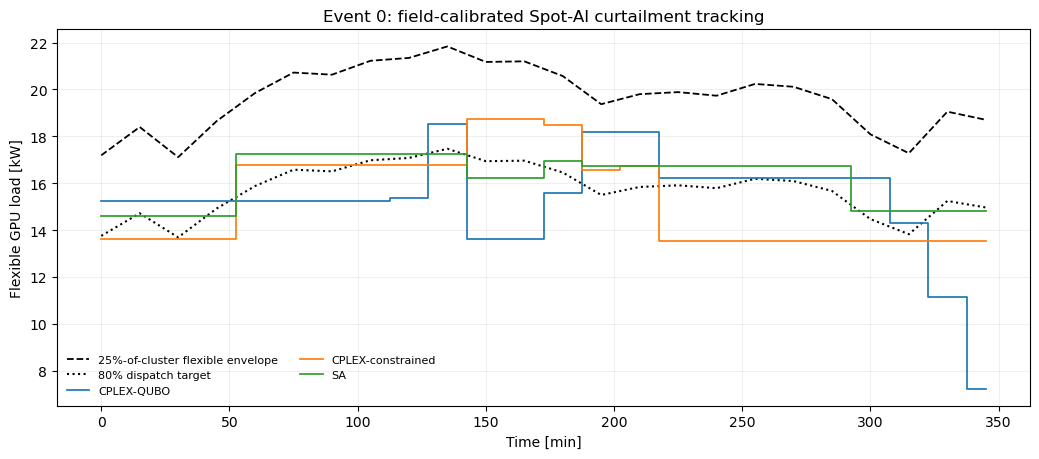

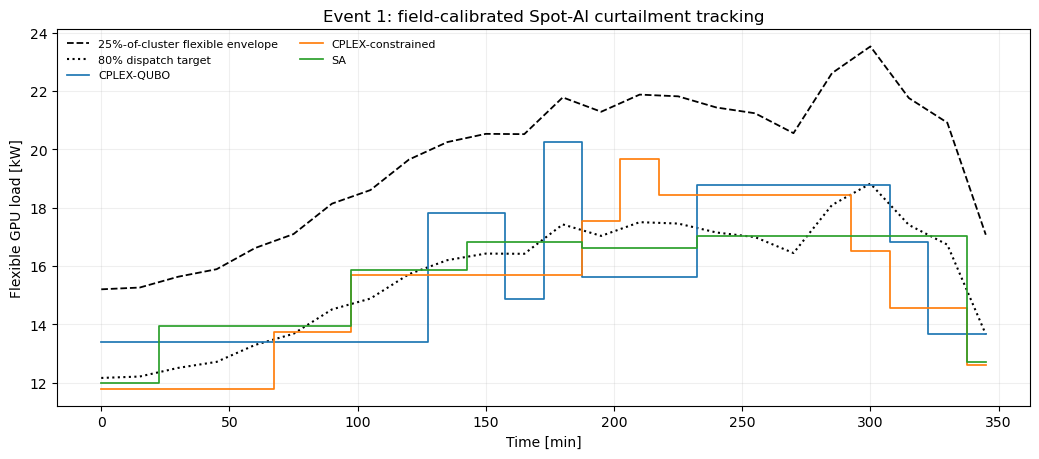

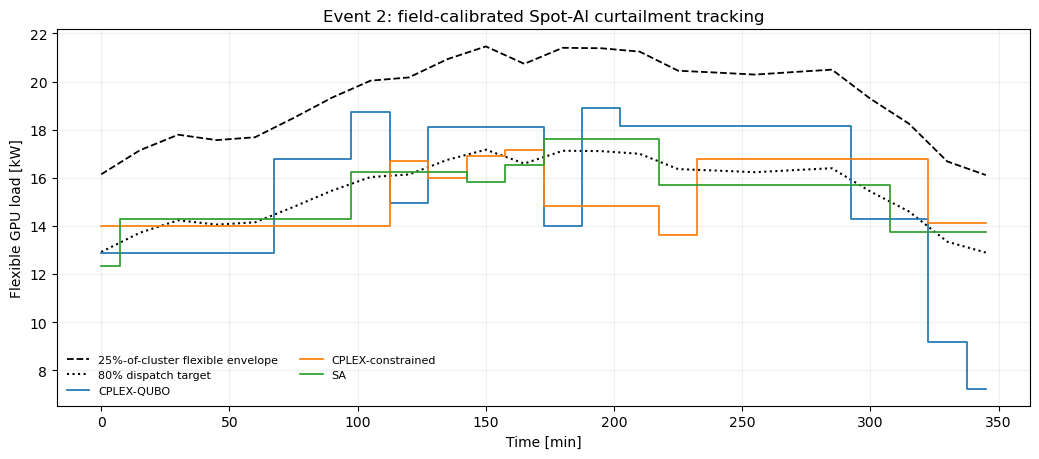

In [6]:
for event_id in SCENARIOS_TO_TEST:
    fig, ax = plt.subplots(figsize=(10.5,4.7))
    ep = profiles[profiles.event_id==event_id].sort_values('slot')
    xx = ep.slot.to_numpy()*CFG.slot_minutes
    ax.plot(xx, ep.allocated_curtailment_kW, 'k--', lw=1.3, label='25%-of-cluster flexible envelope')
    ax.plot(xx, ep.dispatch_target_kW, 'k:', lw=1.5, label='80% dispatch target')
    for method in traj.loc[traj.event_id==event_id,'method'].unique():
        z=traj[(traj.event_id==event_id)&(traj.method==method)].sort_values('slot')
        ax.step(xx,z.gpu_load_kW,where='mid',lw=1.25,label=method)
    ax.set_xlabel('Time [min]'); ax.set_ylabel('Flexible GPU load [kW]')
    ax.set_title(f'Event {event_id}: field-calibrated Spot-AI curtailment tracking')
    ax.grid(alpha=.2); ax.legend(frameon=False,fontsize=8,ncol=2)
    fig.tight_layout(); fig.savefig(OUT/f'event_{event_id:02d}_field_calibrated_tracking.pdf',bbox_inches='tight'); plt.show()

In [7]:
# D-Wave-ready manifest: no remote calls here.
dwave_manifest = events.copy()
dwave_manifest['time_limit_s'] = 30.0
dwave_manifest['qubo_variables'] = manifest['qubo_variables']
dwave_manifest['qubo_edges'] = manifest['qubo_edges']
dwave_manifest['portfolio_seed'] = CFG.seed_jobs
dwave_manifest['field_cluster_gpus'] = CFG.field_cluster_gpus
dwave_manifest['dvfs_caps_W'] = ','.join(map(str,CFG.dvfs_caps_W))
dwave_manifest['field_flex_fraction'] = CFG.field_flex_fraction
dwave_manifest['target_fraction'] = CFG.target_fraction_of_envelope
dwave_manifest.to_csv(OUT/'dwave_20_event_run_manifest_REVISED.csv',index=False)
display(dwave_manifest)
print('Requested future hybrid runtime =',len(dwave_manifest)*30/60,'minutes')

,event_id,start,end,raw_curtailment_MWh,mean_curtailment_MW,max_curtailment_MW,min_curtailment_MW,fraction_positive,time_limit_s,qubo_variables,qubo_edges,portfolio_seed,field_cluster_gpus,dvfs_caps_W,field_flex_fraction,target_fraction
0,0,2025-05-18 10:30:00,2025-05-18 16:15:00,52412.138312,8735.356385,9703.922607,7603.794454,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
1,1,2025-03-18 11:15:00,2025-03-18 17:00:00,52128.136208,8688.022701,10455.091649,6753.784414,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
2,2,2025-03-29 10:15:00,2025-03-29 16:00:00,51534.122713,8589.020452,9537.061124,7160.735733,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
3,3,2025-04-05 10:15:00,2025-04-05 16:00:00,48967.328236,8161.221373,9132.952944,7022.721348,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
4,4,2025-03-15 11:15:00,2025-03-15 17:00:00,48444.136280,8074.022713,9968.503121,6166.478644,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
5,5,2025-03-20 11:00:00,2025-03-20 16:45:00,47229.905466,7871.650911,9351.780381,6519.142495,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
6,6,2025-03-09 10:45:00,2025-03-09 16:30:00,45646.921754,7607.820292,9018.553282,6298.347145,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
7,7,2025-04-20 10:30:00,2025-04-20 16:15:00,44339.966787,7389.994464,9345.964718,5352.268262,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
8,8,2025-04-19 10:30:00,2025-04-19 16:15:00,42273.369176,7045.561529,8337.392675,5667.077878,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8
9,9,2025-04-06 10:15:00,2025-04-06 16:00:00,40604.678070,6767.446345,7164.121782,6055.267734,1.0,30.0,945,419814,883,256,"250,300,350,400",0.25,0.8


Requested future hybrid runtime = 10.0 minutes


## Decision rule

Do **not** run D-Wave yet if the revised QUBO produces duplicate starts or exceeds the allocated curtailment envelope. If those checks pass, the formulation is frozen. The final D-Wave notebook should submit exactly one 30-s `LeapHybridBQMSampler` call for each of the 20 saved event BQMs, with no parameter sweep.

The native constrained CPLEX result remains scientifically important. If it solves all revised events almost instantly, it should be used as a physical/optimality reference rather than hidden; the D-Wave claim should then be about solving the **same dense QUBO representation**, not generic superiority to classical optimization. If the revised native MIQP itself begins to time out or show nontrivial gaps, that materially strengthens the computational story.